In [1]:
import os
import numpy as np
import rasterio
from rasterio import plot
from rasterio.plot import show
import json
from natsort import natsorted
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from shapely.geometry import MultiPolygon
from utils.image_pre_process import normalized_difference, stack_bands, stack_to_geotiff, get_bands, aoi_geojson_reader, aoi_geojson_reader, clip_to_aoi, geojson_to_pixel_polygons, visualize_image_with_polygons, histogram_match, sam_change_detection, otsu_threshold_change, threshold_change
from example_change_detection import compute_change_distance
from utils.geodatabase import binary_raster_to_polygons, remove_small_polygons, merge_touching_polygons, insert_change_features,  insert_aoi, connect_spatialite_database, sync_rasters

## input

In [2]:
raster_path_1 = "data/sentinel2_20230812"
raster_path_2 = "data/sentinel2_20230902"
geojson_path = 'aoi.geojson'

## output

In [3]:
output_1 = 'data/processed/sentinel2_20230812_RGB.tif' # old image
output_2 = 'data/processed/sentinel2_20230902_RGB.tif' # new image
output_hm = 'data/processed/geotiff_hist_match.tif' # image output from histogram match

## get bands from provided sentinel data

In [4]:
bands_1 = get_bands(raster_path_1)
bands_2 = get_bands(raster_path_2)

{'B02': 'data/sentinel2_20230812/B02.tif', 'B03': 'data/sentinel2_20230812/B03.tif', 'B04': 'data/sentinel2_20230812/B04.tif'}
{'B02': 'data/sentinel2_20230902/B02.tif', 'B03': 'data/sentinel2_20230902/B03.tif', 'B04': 'data/sentinel2_20230902/B04.tif'}


### generate RGB images

In [5]:
list_of_bands = ['B02', 'B03', 'B04']
stack_1, raster_meta_1 = stack_bands(list_of_bands, bands_1)
stack_2, raster_meta_2 = stack_bands(list_of_bands, bands_2)

<open DatasetReader name='data/sentinel2_20230812/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 

<open DatasetReader name='data/sentinel2_20230902/B02.tif' mode='r'> 
 0.0 
 EPSG:32735 
 | 10.00, 0.00, 368430.00|
| 0.00,-10.00, 8653770.00|
| 0.00, 0.00, 1.00| 



### save the RGB images

In [6]:
stack_to_geotiff(stack_1, raster_meta_1, output_1)
stack_to_geotiff(stack_2, raster_meta_1, output_2)

### match new image histogram (source) with histogram from old image (reference). reference has less noise

In [ ]:
# histogram match pre-processing
source = stack_2
reference = stack_1
image_hm = histogram_match(source, reference)
stack_to_geotiff(image_hm, raster_meta_1, output_hm)

## change detection: Change Vector Analysis (CVA) vs Spectral Angle Mapper (SAM) 

In [7]:
# stack = stack.astype(np.float32)
# demo algorythm
change_detection = compute_change_distance(stack_1.astype(np.float32), stack_2.astype(np.float32))
change_detection_w_histm = compute_change_distance(stack_1.astype(np.float32), image_hm.astype(np.float32))

change_detection_sam = sam_change_detection(stack_1.astype(np.float32), stack_2.astype(np.float32))
change_detection_sam_w_histm = sam_change_detection(stack_1.astype(np.float32), image_hm.astype(np.float32))

#### save cva, sam images

In [8]:
stack_to_geotiff(change_detection[0], raster_meta_1, 'data/processed/change.tif')
stack_to_geotiff(change_detection[1], raster_meta_1, 'data/processed/change_probability.tif')

stack_to_geotiff(change_detection_sam[0], raster_meta_1, 'data/processed/change_sam.tif')
stack_to_geotiff(change_detection_sam[1], raster_meta_1, 'data/processed/change_probability_sam.tif')

#### plot cva, sam images with and without histogram match

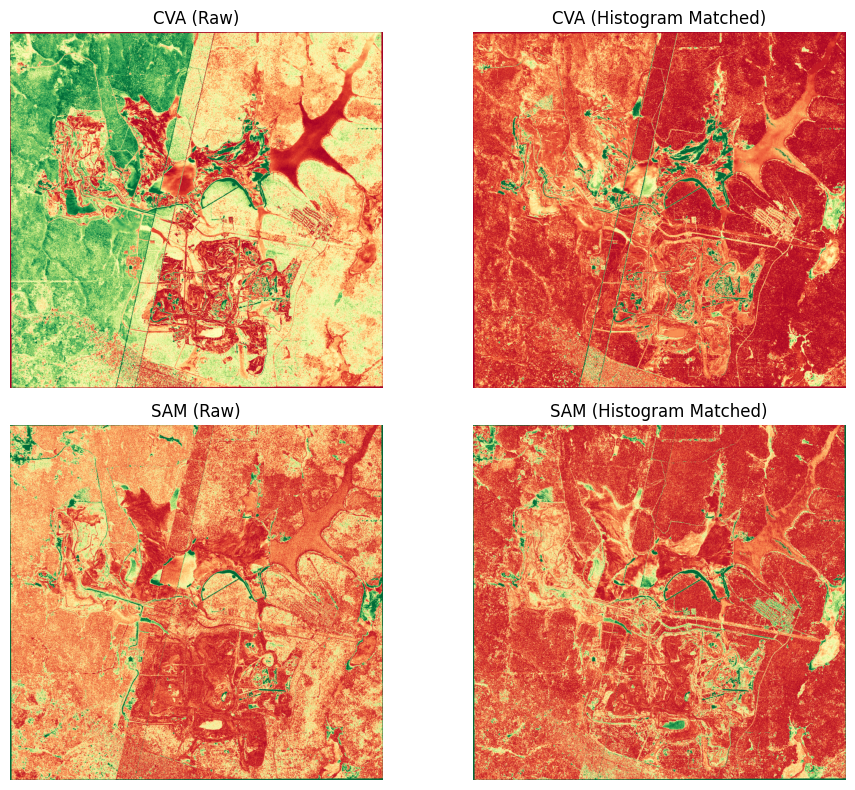

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(change_detection[0], cmap="RdYlGn", vmin=np.percentile(change_detection[0], 2), vmax=np.percentile(change_detection[0], 98))
axes[0, 0].set_title("CVA (Raw)")
axes[0, 0].axis("off")

axes[0, 1].imshow(change_detection_w_histm[0], cmap="RdYlGn", vmin=np.percentile(change_detection_w_histm[0], 2), vmax=np.percentile(change_detection_w_histm[0], 98))
axes[0, 1].set_title("CVA (Histogram Matched)")

axes[0, 1].axis("off")

axes[1, 0].imshow(change_detection_sam[0], cmap="RdYlGn", vmin=np.percentile(change_detection_sam[0], 2), vmax=np.percentile(change_detection_sam[0], 98))
axes[1, 0].set_title("SAM (Raw)")
axes[1, 0].axis("off")

axes[1, 1].imshow(change_detection_sam_w_histm[0], cmap="RdYlGn", vmin=np.percentile(change_detection_sam_w_histm[0], 2), vmax=np.percentile(change_detection_sam_w_histm[0], 98))
axes[1, 1].set_title("SAM (Histogram Matched)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### get aoi and visualize image with polygon

In [8]:
geojson_dict = aoi_geojson_reader(geojson_path)

pixel_polygons = geojson_to_pixel_polygons(geojson_dict, raster_meta_1)

visualize_image_with_polygons(stack_1, pixel_polygons, title="AOI Overlay")

#### extracting binary change detection by threshold 

In [9]:
# USING CVA WITH HISTOGRAM MATCH

# thereshold is based on ground truth (visual change of recognized object by cpmparing 2 images (before and after))
binary_cd_threshold_cva = threshold_change(change_detection_w_histm[1], percentile=98)

binary_cd_auto_otsu_cva = otsu_threshold_change(change_detection_w_histm[1])

In [10]:
# USING SAM WITH HISTOGRAM MATCH

# thereshold is based on ground truth (visual change of recognized object by cpmparing 2 images (before and after))
binary_cd_threshold_sam = threshold_change(change_detection_sam_w_histm[1], percentile=98)

binary_cd_auto_otsu_sam = otsu_threshold_change(change_detection_sam_w_histm[1])

#### plot change detection binary output: manual threshold vs auto threshold (otsu)

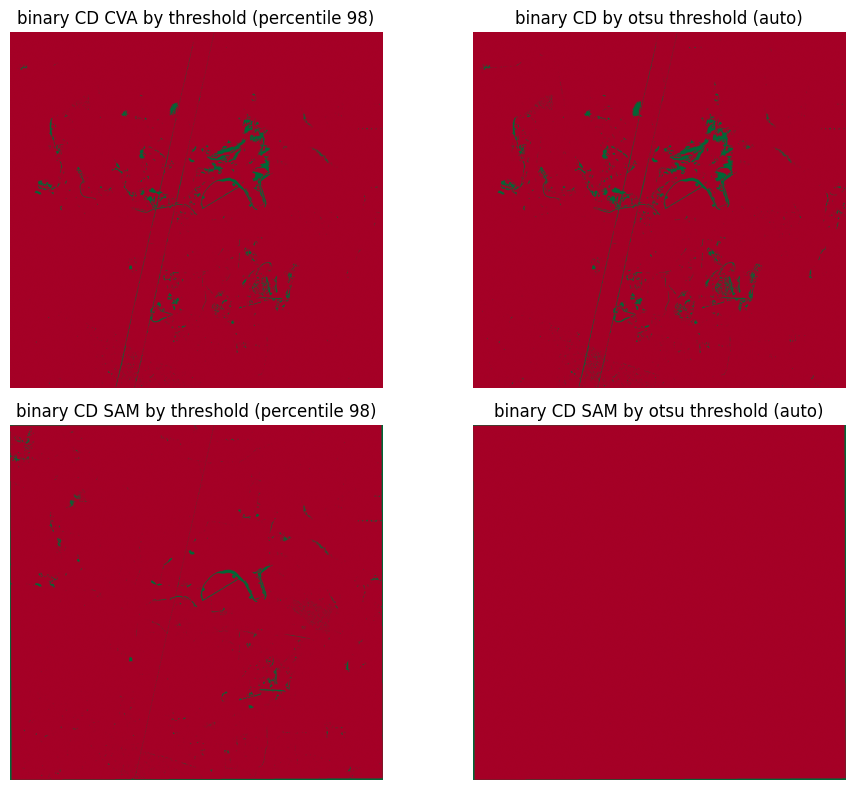

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(binary_cd_threshold_cva, cmap="RdYlGn")
axes[0, 0].set_title("binary CD CVA by threshold (percentile 98)")
axes[0, 0].axis("off")

axes[0, 1].imshow(binary_cd_auto_otsu_cva, cmap="RdYlGn")
axes[0, 1].set_title("binary CD by otsu threshold (auto)")
axes[0, 1].axis("off")

axes[1, 0].imshow(binary_cd_threshold_sam, cmap="RdYlGn")
axes[1, 0].set_title("binary CD SAM by threshold (percentile 98)")
axes[1, 0].axis("off")

axes[1, 1].imshow(binary_cd_auto_otsu_sam, cmap="RdYlGn")
axes[1, 1].set_title("binary CD SAM by otsu threshold (auto)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

#### save selected binary change detection: cva (auto) and sam (manual)

In [11]:
stack_to_geotiff(binary_cd_threshold_sam, raster_meta_1, 'data/processed/binary_cd_threshold_98_sam.tif')
stack_to_geotiff(binary_cd_auto_otsu_cva, raster_meta_1, 'data/processed/binary_cd_auto_otsu_cva.tif')

### save data into the database (spatialite). Assuming that db is already created from debug_geodatabase notebook

In [11]:
spatialite_dll_path=r"C:\Program Files\QGIS 3.34.3\bin\mod_spatialite.dll"
conn = connect_spatialite_database(
    "data/change_database.sqlite",
    spatialite_dll_path
)

#### saving binary change detection into database as vector

In [15]:

polygons = binary_raster_to_polygons(binary_cd_threshold_sam, raster_meta_1["transform"])

polygons = clip_to_aoi(polygons, geojson_dict)

polygons = remove_small_polygons(polygons, min_area_m2=1000)

polygons = merge_touching_polygons(polygons)

multi_polygons = [MultiPolygon([p]) for p in polygons]

In [17]:
insert_change_features(
    conn,
    polygons=multi_polygons,
    date_before="2023-08-12",
    date_after="2023-09-02",
    method="SAM",
    srid=32735
)

#### save aoi from geojson into the database

In [18]:

insert_aoi(conn, geojson_dict, "mine_aoi", srid=32735)

#### save/sync output raster path into the database

In [12]:

sync_rasters(conn, "data/processed")

Added: data/processed/binary_cd_auto_otsu_cva.tif
Added: data/processed/binary_cd_threshold_98_sam.tif
Added: data/processed/change.tif
Added: data/processed/change_probability.tif
Added: data/processed/change_probability_sam.tif
Added: data/processed/change_sam.tif
Added: data/processed/geotiff_hist_match.tif
Added: data/processed/sentinel2_20230812_RGB.tif
Added: data/processed/sentinel2_20230902_RGB.tif

Sync complete — added 9, removed 0
